In [1]:
#code that preprocesses data and fits a GLM per neuron to predict neural activity from position
#note that goodness of fit criteria may not apply to other datasets, users should carefully inspect each model fit
#for quality, which are all outputted

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import csv
import copy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import glob
import math
import re
#import cv2
from scipy.stats import entropy
import sys
import time as ti  # for timing
import seaborn as sns
import nemos as nmo

from scipy.spatial.distance import cosine
#import numpy as np

36


C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_x'] = pd.to_numeric(data['player_position_x'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_y'] = pd.to_numeric(data['player_position_y'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

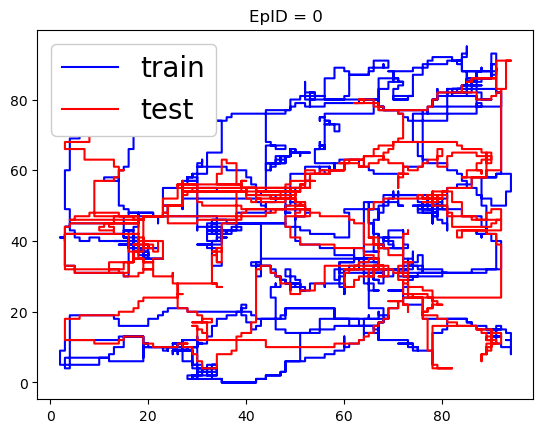

36


C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_x'] = pd.to_numeric(data['player_position_x'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_y'] = pd.to_numeric(data['player_position_y'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

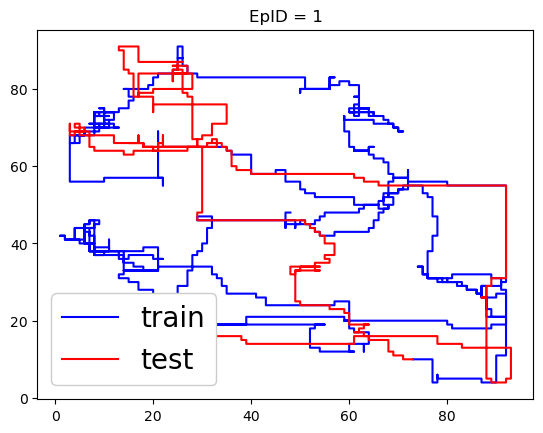

36


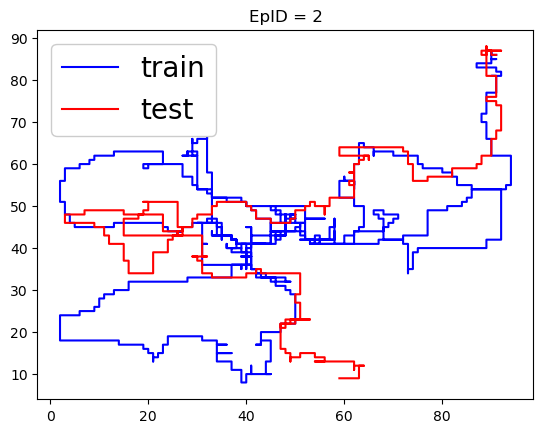

36


C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_x'] = pd.to_numeric(data['player_position_x'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_y'] = pd.to_numeric(data['player_position_y'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

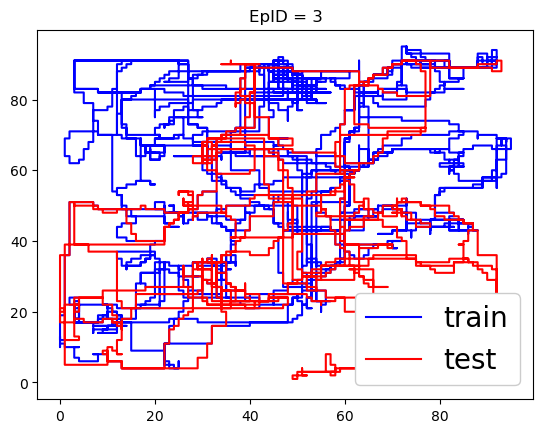

36


C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_x'] = pd.to_numeric(data['player_position_x'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['player_position_y'] = pd.to_numeric(data['player_position_y'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2523591340.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

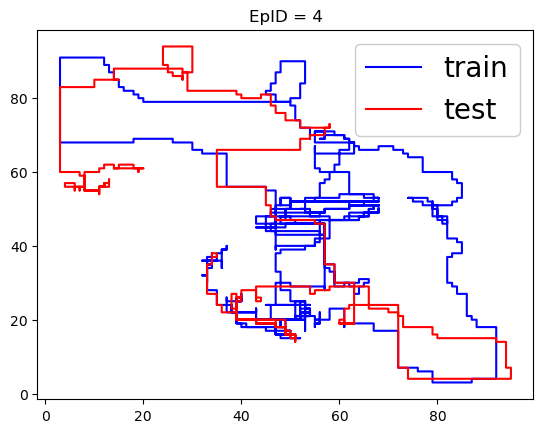

36


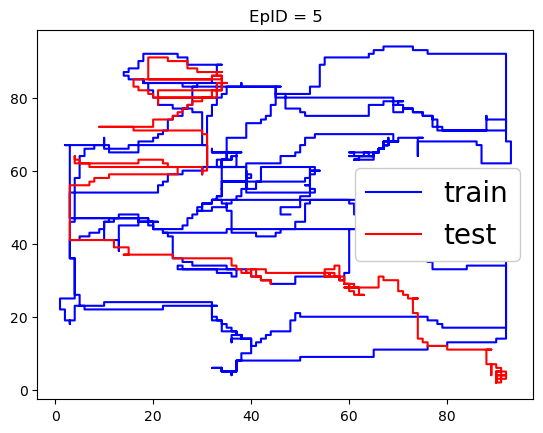

In [2]:
#Merge behavior (scalars.csv) and neural data (hstates.csv)

RunKey = 2 #choose which run/init state to analyze

if RunKey == 0: #path int, jan2025 baseline, fype4js7

    #directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/ForageWorldGLM/Data/'
    directoryPath0 = 'C:/Users/chris/Documents/GitHub/Data/fype4js7/'
    #directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/fype4js7/'
    #dirPop = 'C:/Users/ryanb/Documents/GitHub/ForageWorldGLM/population/'
    dirPop = 'C:/Users/chris/Documents/GitHub/Data/population/'
    #dirPop = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/population/'

    file_name1a = directoryPath0 + 'scalars_67584_0.csv'
    file_name2a = directoryPath0 + 'hstates_67584_0.csv'
    
    file_name1b = directoryPath0 + 'scalars_65536_0.csv'
    file_name2b = directoryPath0 + 'hstates_65536_0.csv'
    
    #file_name1c = directoryPath0 + 'scalars_69632_0.csv'
    #file_name2c = directoryPath0 + 'hstates_69632_0.csv'
    
    file_name1c = directoryPath0 + 'scalars_71680_0.csv'
    file_name2c = directoryPath0 + 'hstates_71680_0.csv'
    
    file_name1d = directoryPath0 + 'scalars_61440_0.csv'
    file_name2d = directoryPath0 + 'hstates_61440_0.csv'
    
    file_name1 = [file_name1a,file_name1b,file_name1c,file_name1d]
    file_name2 = [file_name2a,file_name2b,file_name2c,file_name2d]

if RunKey == 1:
        
    #directoryPath0 = 'C:/Users/chris/Documents/GitHub/Data/ivheiklj/'
    directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/foraging_no_pathint_72h_05_05_25_0/lvheiklj/'
    #dirPop = 'C:/Users/chris/Documents/GitHub/Data/population/'
    dirPop = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/population/'

    file_name1a = directoryPath0 + 'scalars_67584_0.csv'
    file_name2a = directoryPath0 + 'hstates_67584_0.csv'
    
    file_name1b = directoryPath0 + 'scalars_73728_0.csv'
    file_name2b = directoryPath0 + 'hstates_73728_0.csv'
    
    file_name1e = directoryPath0 + 'scalars_69632_0.csv'
    file_name2e = directoryPath0 + 'hstates_69632_0.csv'
    
    file_name1c = directoryPath0 + 'scalars_71680_0.csv'
    file_name2c = directoryPath0 + 'hstates_71680_0.csv'
    
    file_name1d = directoryPath0 + 'scalars_61440_0.csv'
    file_name2d = directoryPath0 + 'hstates_61440_0.csv'
    
    file_name1 = [file_name1a,file_name1b,file_name1c,file_name1d,file_name1e]
    file_name2 = [file_name2a,file_name2b,file_name2c,file_name2d,file_name2e]
    
if RunKey == 2:
        
    #directoryPath0 = 'C:/Users/chris/Documents/GitHub/Data/ivheiklj/'
    #directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/foraging_no_pathint_72h_05_05_25_0/lvheiklj/'
    directoryPath0 = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/o0z9yo3j_baselineMay/'
    #dirPop = 'C:/Users/chris/Documents/GitHub/Data/population/'
    dirPop = 'C:/Users/ryanb/Documents/GitHub/GLM_Data/population/'

    #file_name1a = directoryPath0 + 'scalars_67584_0.csv'
    #file_name2a = directoryPath0 + 'hstates_67584_0.csv'
    file_name1a = directoryPath0 + 'scalars_75776_0.csv'
    file_name2a = directoryPath0 + 'hstates_75776_0.csv'

    #file_name1b = directoryPath0 + 'scalars_73728_0.csv'
    #file_name2b = directoryPath0 + 'hstates_73728_0.csv'
    file_name1b = directoryPath0 + 'scalars_83968_0.csv'
    file_name2b = directoryPath0 + 'hstates_83968_0.csv'

    file_name1c = directoryPath0 + 'scalars_63488_0.csv'
    file_name2c = directoryPath0 + 'hstates_63488_0.csv'
    
    file_name1d = directoryPath0 + 'scalars_61440_0.csv'
    file_name2d = directoryPath0 + 'hstates_61440_0.csv'
    
    file_name1e = directoryPath0 + 'scalars_90112_0.csv'
    file_name2e = directoryPath0 + 'hstates_90112_0.csv'
    
    file_name1f = directoryPath0 + "scalars_88064_0.csv"
    file_name2f = directoryPath0 + "hstates_88064_0.csv"
    
    file_name1 = [file_name1a,file_name1b,file_name1c,file_name1d,file_name1e,file_name1f]
    file_name2 = [file_name2a,file_name2b,file_name2c,file_name2d,file_name2e,file_name2f]    

x_min, x_max = 0, 95 #arena size in the jax task
y_min, y_max = 0, 95
num_bins_x = 14 # number of bins to coarse-grain the arena for analysis
num_bins_y = 14
numEp = len(file_name1)
cut = 0.7 #test/train cut 70% of data is train if 0.7
start_cut = 250 # initial amount of timesteps to cut, episode transitions have transient activity
numExtraFactors = 0 # food, energy, drink in GLM or not, if == 0 only binary position bin regressors are used
nNeurons = 512 # number of neurons in the LSTM/GRU
countFactor = 1 

ep_idx0 = 2000 #used for slope criteria to omit in goodness of fit criteria below
ep_idx1 = 10000

ep_time_transitions_train = []
ep_time_transitions_test = []

# merges several episodes into one long time series and then does test/train divisions per episode
for ep_id in range(numEp):
    

    beh_data = pd.read_csv(file_name1[ep_id], low_memory=False)
    neur_data = pd.read_csv(file_name2[ep_id], low_memory=False, header=None)

    #Ldata = len(beh_data['pred_delta_x'])
    beh_data.drop(beh_data[beh_data['pred_delta_x'] == 'pred_delta_x'].index, inplace = True)
    beh_data.reset_index(drop=True, inplace=True)

    merged_data = pd.concat([beh_data, neur_data], axis=1)
    #print(merged_data)

    #fit just one episode 
    x_no_first_ep = merged_data.copy(deep=True)            
    x_no_first_ep.drop(x_no_first_ep[x_no_first_ep['episode_id'] == merged_data.loc[0,'episode_id']].index, inplace = True)  
    x_no_first_ep.reset_index(drop=True, inplace=True)

    # only look at episodes where one can see the t=0 point for an episode, thus always skip first id in a csv
    data = x_no_first_ep[x_no_first_ep['episode_id'] == x_no_first_ep.loc[0,'episode_id']]  
    #print(final_data)

    neural_idx0 = data.columns.get_loc(0)
    print(neural_idx0) # index of first neural column
    
    # light preprocessing
    #data['time'] = np.arange(len(data))
    data['player_position_x'] = pd.to_numeric(data['player_position_x'])
    data['player_position_y'] = pd.to_numeric(data['player_position_y'])
    data['food'] = pd.to_numeric(data['food'])
    data['drink'] = pd.to_numeric(data['drink'])
    data['energy'] = pd.to_numeric(data['energy'])

    for col in  data.columns[neural_idx0:]:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    
    
    x_t = data['player_position_x']
    y_t = data['player_position_y']
    food_t = data['food']
    energy_t = data['energy']
    drink_t = data['drink']

    #time = data['time']
    
    
    
    num_t_pts = len(x_t)
    ind_cut = int(cut*num_t_pts)
    counts = data.iloc[:, neural_idx0:]
    
    # shows the movement trajectories divided into test/train per episode
    plt.plot(x_t[:ind_cut], y_t[:ind_cut], color='blue', label='train')
    plt.plot(x_t[ind_cut:], y_t[ind_cut:], color='red', label='test')
    titleStr = "EpID = " + str(ep_id)
    plt.title(titleStr)
    plt.legend(fontsize=20,framealpha=1)
    plt.show()

    if ep_id == 0:
        #time_train, time_test = time[start_cut:ind_cut], time[ind_cut:]
        x_train, x_test = x_t[start_cut:ind_cut], x_t[ind_cut:]
        y_train, y_test = y_t[start_cut:ind_cut], y_t[ind_cut:]
        food_train, food_test = food_t[start_cut:ind_cut], food_t[ind_cut:]
        energy_train, energy_test = energy_t[start_cut:ind_cut], energy_t[ind_cut:]
        drink_train, drink_test = drink_t[start_cut:ind_cut], drink_t[ind_cut:]
        counts_train, counts_test = counts.iloc[start_cut:ind_cut,:], counts.iloc[ind_cut:,:]
        
        food_train.reset_index(drop=True, inplace=True)
        energy_train.reset_index(drop=True, inplace=True)
        drink_train.reset_index(drop=True, inplace=True)
        food_test.reset_index(drop=True, inplace=True)
        energy_test.reset_index(drop=True, inplace=True)
        drink_test.reset_index(drop=True, inplace=True)
        
        ep_time_transitions_train.append(len(x_train))
        ep_time_transitions_test.append(len(x_test))
        
    if ep_id > 0:
        #time_train_0, time_test_0 = time[start_cut:ind_cut], time[ind_cut:]
        x_train_0, x_test_0 = x_t[start_cut:ind_cut], x_t[ind_cut:]
        y_train_0, y_test_0 = y_t[start_cut:ind_cut], y_t[ind_cut:]
        food_train_0, food_test_0 = food_t[start_cut:ind_cut], food_t[ind_cut:]
        energy_train_0, energy_test_0 = energy_t[start_cut:ind_cut], energy_t[ind_cut:]
        drink_train_0, drink_test_0 = drink_t[start_cut:ind_cut], drink_t[ind_cut:]    
        counts_train_0, counts_test_0 = counts.iloc[start_cut:ind_cut,:], counts.iloc[ind_cut:,:]
    
        food_train_0.reset_index(drop=True, inplace=True)
        energy_train_0.reset_index(drop=True, inplace=True)
        drink_train_0.reset_index(drop=True, inplace=True)
        food_test_0.reset_index(drop=True, inplace=True)
        energy_test_0.reset_index(drop=True, inplace=True)
        drink_test_0.reset_index(drop=True, inplace=True)
        
        
        #time_train = pd.concat([time_train,time_train_0])
        #time_test = pd.concat([time_test,time_test_0])
        x_train = pd.concat([x_train,x_train_0])
        x_test = pd.concat([x_test,x_test_0])
        y_train = pd.concat([y_train,y_train_0])
        y_test = pd.concat([y_test,y_test_0])
        food_train = pd.concat([food_train,food_train_0])
        food_test = pd.concat([food_test,food_test_0])
        energy_train = pd.concat([energy_train,energy_train_0])
        energy_test = pd.concat([energy_test,energy_test_0])
        drink_train = pd.concat([drink_train,drink_train_0])
        drink_test = pd.concat([drink_test,drink_test_0])
        counts_train = pd.concat([counts_train,counts_train_0])
        counts_test = pd.concat([counts_test,counts_test_0])
        
        #time_train.reset_index(drop=True, inplace=True)
        food_train.reset_index(drop=True, inplace=True)
        energy_train.reset_index(drop=True, inplace=True)
        drink_train.reset_index(drop=True, inplace=True)
        #time_test.reset_index(drop=True, inplace=True)
        food_test.reset_index(drop=True, inplace=True)
        energy_test.reset_index(drop=True, inplace=True)
        drink_test.reset_index(drop=True, inplace=True)

        ep_time_transitions_train.append(len(x_train))
        ep_time_transitions_test.append(len(x_test))


time_train = np.arange(len(x_train))
time_test = np.arange(len(x_test))
dt = time_train[1] - time_train[0]
#HD_train, HD_test = HD_t[:ind_cut], HD_t[ind_cut:]             # FILL IN
#speed_train, speed_test = speed_t[:ind_cut], speed_t[ind_cut:]

 # counts[:ind_cut,:], counts[ind_cut:,:]


In [3]:
#the episode transition timepoints
print(ep_time_transitions_train)
print(ep_time_transitions_test)

[16068, 20225, 23996, 37956, 42150, 46732]
[6994, 8884, 10608, 16698, 18603, 20675]


C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\220307134.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['time'] = np.arange(len(data))


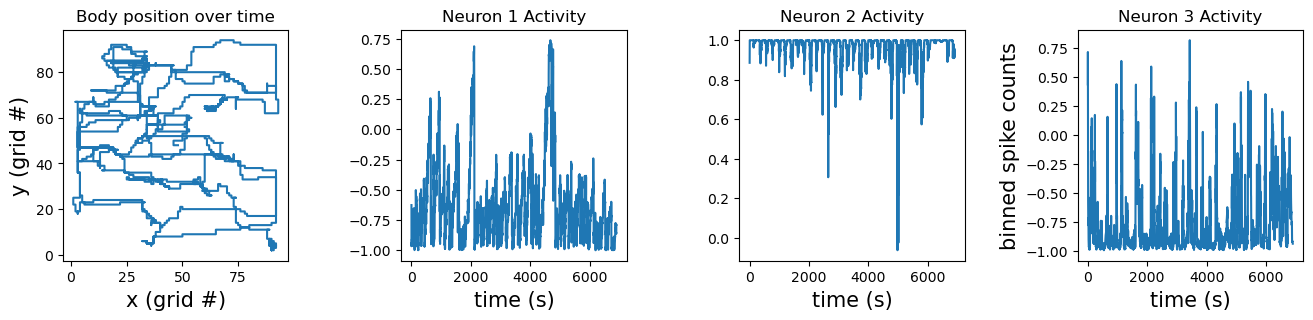

In [4]:
# some plots for the last run in the loop above, just a check

neuron1 = 30    
neuron2 = 21  
neuron3 = 22   

#plot data
data['time'] = np.arange(len(data))
fig, ax = plt.subplots(ncols=4, figsize=(16, 3))

ax[0].plot(data['player_position_x'], data['player_position_y'])
ax[0].set_xlabel('x (grid #)', fontsize=15); ax[0].set_ylabel('y (grid #)', fontsize=15)
ax[0].set_title('Body position over time')

ax[1].plot(data['time'], data[neural_idx0 + neuron1])        # only visualize first neuron
ax[1].set_xlabel('time (s)', fontsize=15); ax[3].set_ylabel('binned spike counts', fontsize=15)
ax[1].set_title('Neuron 1 Activity')

ax[2].plot(data['time'], data[neural_idx0 + neuron2])        # only visualize first neuron
ax[2].set_xlabel('time (s)', fontsize=15); ax[3].set_ylabel('binned spike counts', fontsize=15)
ax[2].set_title('Neuron 2 Activity')

ax[3].plot(data['time'], data[neural_idx0 + neuron3])        # only visualize first neuron
ax[3].set_xlabel('time (s)', fontsize=15); ax[3].set_ylabel('binned spike counts', fontsize=15)
ax[3].set_title('Neuron 3 Activity')

plt.subplots_adjust(wspace=0.5)
plt.show()

In [5]:
# Position bins
bins_x = np.linspace(x_min, x_max, num_bins_x )
bins_y = np.linspace(y_min, y_max, num_bins_y )
print(bins_x)

[ 0.          7.30769231 14.61538462 21.92307692 29.23076923 36.53846154
 43.84615385 51.15384615 58.46153846 65.76923077 73.07692308 80.38461538
 87.69230769 95.        ]


In [6]:
def bin_behavior(x_t, y_t,bins_x,bins_y):
    x_dig = np.digitize(x_t, bins=bins_x) -1; x_dig = np.clip(x_dig, 0, num_bins_x-1)
    y_dig = np.digitize(y_t, bins=bins_y) -1; y_dig = np.clip(y_dig, 0, num_bins_y-1)
    #HD_dig = np.digitize(HD_t, bins=bins_HD) -1; HD_dig = np.clip(HD_dig, 0, num_bins_HD-1) # YOU FILL IN
    #speed_dig = np.digitize(speed_t, bins=bins_speed) - 1; speed_dig = np.clip(speed_dig, 0, num_bins_speed-1)

    return x_dig, y_dig #, HD_dig, speed_dig

In [7]:
xd_train, yd_train = bin_behavior(x_train, y_train,bins_x,bins_y)
xd_test, yd_test = bin_behavior(x_test, y_test,bins_x,bins_y)

print(xd_train.shape)
print('Same shape as before, but this array contains indices that indicate which bin the current value falls in.')
print('For memory reasons, this is better than explicitly storing a time points x num_bins matrix.')

(46732,)
Same shape as before, but this array contains indices that indicate which bin the current value falls in.
For memory reasons, this is better than explicitly storing a time points x num_bins matrix.


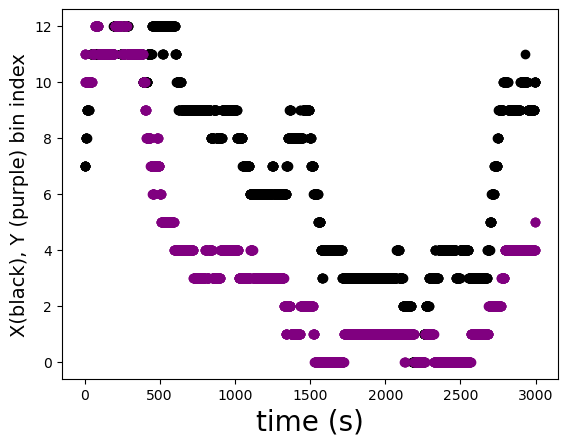

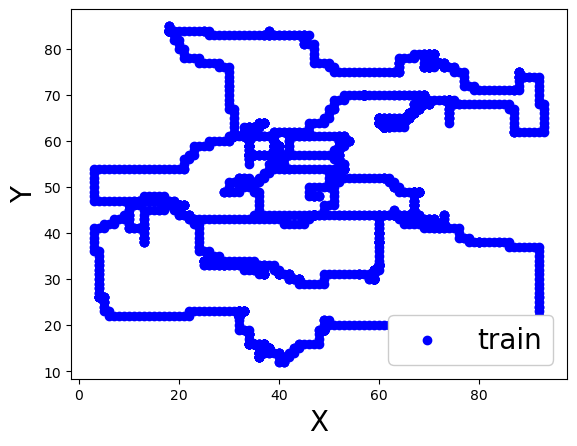

In [8]:
#check how bin position changes over time in a sample of data
ind_max = 3000
plt.scatter(time_train[:ind_max], xd_train[:ind_max],color='k')
plt.scatter(time_train[:ind_max], yd_train[:ind_max],color='purple')
plt.xlabel('time (s)', fontsize=20)
plt.ylabel('X(black), Y (purple) bin index', fontsize=14)
plt.show()

plt.scatter(x_t[:ind_max], y_t[:ind_max], color='blue', label='train')
plt.legend(fontsize=20,framealpha=1)
plt.xlabel('X', fontsize=20)
plt.ylabel('Y', fontsize=20)
plt.show()

In [9]:
#example single neuron fit, code blocks after do the full population

neuronID = 30

pos_bins_train = np.vstack((xd_train, yd_train)).T
pos_bins_test = np.vstack((xd_test, yd_test)).T


pos_factors_train = np.zeros((np.shape(pos_bins_train)[0], num_bins_x*num_bins_y + numExtraFactors))
pos_factors_test = np.zeros((np.shape(pos_bins_test)[0], num_bins_x*num_bins_y + numExtraFactors))

bin_key_x = np.ones((num_bins_x*num_bins_y))*-1
bin_key_y = np.ones((num_bins_x*num_bins_y))*-1

dR_t = np.zeros((np.shape(pos_bins_train)[0],1))

#binarize into factor variable for all possible bins
for t in range(np.shape(pos_bins_train)[0]):
    binID = pos_bins_train[t,0]*num_bins_x + pos_bins_train[t,1]
    pos_factors_train[t,binID] = 1
    bin_key_x[binID] = pos_bins_train[t,0]
    bin_key_y[binID] = pos_bins_train[t,1]

    dXbin =  pos_bins_train[t,0] - (num_bins_x-1)/2
    dYbin =  pos_bins_train[t,1] - (num_bins_y-1)/2
    
    dR_t[t] = int( np.sqrt(dXbin*dXbin + dYbin*dYbin ) )


# if numExtraFactors == 3 then can add energy, drink and food to GLM. For now we only study position, thus == 0
for t in range(np.shape(pos_bins_test)[0]):
    binID = pos_bins_test[t,0]*num_bins_x + pos_bins_test[t,1]
    pos_factors_test[t,binID] = 1

for i in range(numExtraFactors):
    for t in range(np.shape(pos_bins_train)[0]):
        if i == 0:
            pos_factors_train[t,-1*(i+1)] = food_train[t]
        if i == 1:
            pos_factors_train[t,-1*(i+1)] = drink_train[t]
        if i == 2:
            pos_factors_train[t,-1*(i+1)] = energy_train[t]    
            
for i in range(numExtraFactors):
    for t in range(np.shape(pos_bins_test)[0]):
        if i == 0:
            pos_factors_test[t,-1*(i+1)] = food_test[t]
        if i == 1:
            pos_factors_test[t,-1*(i+1)] = drink_test[t]
        if i == 2:
            pos_factors_test[t,-1*(i+1)] = energy_test[t]                
    
#neural data    
counts_train_raw = counts_train.iloc[:, neuronID].to_numpy()
counts_test_raw = counts_test.iloc[:, neuronID].to_numpy()

# shift neural data above 0 and make abs() for GLM machinery, normalize all traces between 0 and 1 for interpretability 
minVal =  np.min(counts_train_raw)
if np.min(counts_test_raw) < minVal:
    minVal = np.min(counts_test_raw)

counts_train_zeroed0 = counts_train_raw - minVal
counts_test_zeroed0 = counts_test_raw - minVal

counts_train_zeroed = countFactor * counts_train_zeroed0 / np.max(counts_train_zeroed0)
counts_test_zeroed = countFactor * counts_test_zeroed0 / np.max(counts_test_zeroed0)

print(counts_train_zeroed)

# Instantiate the single model
model = nmo.glm.GLM()

# define fit the model
model = model.fit(pos_factors_train,counts_train_zeroed)

[0.9430845  0.94157192 0.94335848 ... 0.56154681 0.56173273 0.56192435]


In [10]:
print(food_train[1])

1.0


In [11]:
# model coefficients shape is (num_features, ), num of binX x num of binY
print(f"Model coefficients shape: {model.coef_.shape}")

# model intercept, shape (1,) since there is only one neuron.
print(f"Model intercept shape: {model.intercept_.shape}")

Model coefficients shape: (196,)
Model intercept shape: (1,)


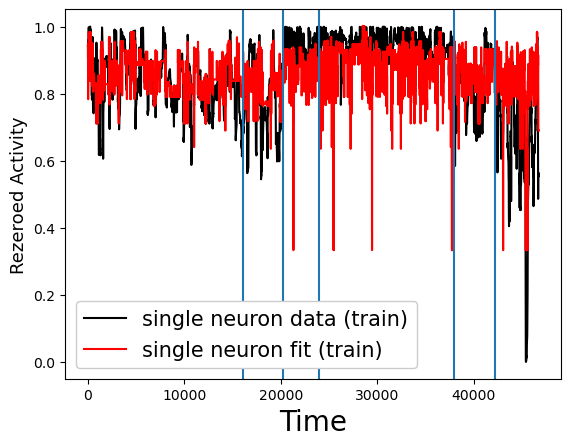

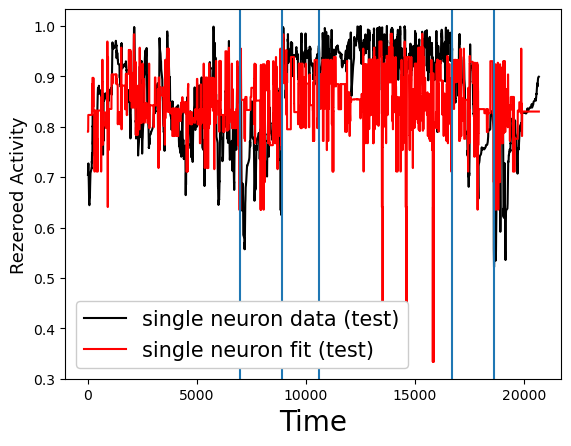

trainLL:  -0.93797195 testLL:  -0.9416882


In [12]:
# predict the rate
predicted_rate_train = model.predict(pos_factors_train)
predicted_rate_test = model.predict(pos_factors_test)
# firing rate has shape: (num_samples,)
predicted_rate_train.shape

#plt.plot(time_train, counts_train_raw,color='gray')
plt.plot(time_train, counts_train_zeroed,color='k',label='single neuron data (train)')
plt.plot(time_train, predicted_rate_train,color='r',label='single neuron fit (train)')
for i in range(len(ep_time_transitions_train)-1):
    plt.axvline(x=ep_time_transitions_train[i])
plt.legend(fontsize=15,framealpha=1)
plt.xlabel('Time', fontsize=20)
plt.ylabel('Rezeroed Activity', fontsize=13)
plt.show()

plt.plot(time_test, counts_test_zeroed,color='k',label='single neuron data (test)')
plt.plot(time_test, predicted_rate_test,color='r',label='single neuron fit (test)')
for i in range(len(ep_time_transitions_test)-1):
    plt.axvline(x=ep_time_transitions_test[i])
plt.legend(fontsize=15,framealpha=1)
plt.xlabel('Time', fontsize=20)
plt.ylabel('Rezeroed Activity', fontsize=13)
plt.show()

# compute the log-likelihood of the model
log_likelihood_train = model.score(pos_factors_train, counts_train_zeroed)
log_likelihood_test = model.score(pos_factors_test, counts_test_zeroed)
print('trainLL: ', log_likelihood_train, 'testLL: ', log_likelihood_test)

In [13]:
# model coefficients shape is (num_features, num_neurons)
print(f"Model coefficients shape: {model.coef_.shape[0]}")

# model intercept, (num_neurons,)
print(f"Model intercept shape: {model.intercept_.shape}")

Model coefficients shape: 196
Model intercept shape: (1,)


In [14]:
#single neuron's regressors vs position

weight_plot = np.ones((num_bins_x, num_bins_y))*-0.05
max_weight_plot = np.ones((num_bins_x, num_bins_y))*-0.05
max_weight_ids = np.ones((num_bins_x, num_bins_y))*-1

print(weight_plot[0,0])
for i in range(model.coef_.shape[0]-numExtraFactors):
    #print(bin_key_x[i], ', ', bin_key_y[i])
    if bin_key_x[i] > -1:
       weight_plot[int(bin_key_x[i]),int(bin_key_y[i])] =  abs(model.coef_[i])
    

-0.05


In [15]:
# Fit full population of neurons now, "Good" plots meet all goodness of fit criteria

# GLM coefficient matricies, will also calculate average and max GLM coefficients
weight_plot = np.ones((num_bins_x, num_bins_y))*-0.05
max_weight_plot = np.ones((num_bins_x, num_bins_y))*-0.05
max_weight_ids = np.ones((num_bins_x, num_bins_y))*-1

GoodWeightList = []
GoodWeightListAbs = []
GoodWeightdX = []
GoodWeightdY = []

#print(weight_plot[0,0])


#num_samples, num_features, num_neurons = 100, 3, 5
alpVal = 0.6 # plotting transparency for later
#population_model = nmo.glm.PopulationGLM()
test_LL = []
train_LL = []

test_cs = []
train_cs = []

test_p = []
train_p = []

train_std_zeroed = []
test_std_zeroed = []
train_std_predicted = []
test_std_predicted = []

counts_train_raw_pop = counts_train.iloc[:, :].to_numpy()
counts_test_raw_pop = counts_test.iloc[:, :].to_numpy()

counts_train_zeroed_pop0 = counts_train.iloc[:, :].to_numpy()
counts_test_zeroed_pop0 = counts_test.iloc[:, :].to_numpy()

counts_train_zeroed_pop = counts_train.iloc[:, :].to_numpy()
counts_test_zeroed_pop = counts_test.iloc[:, :].to_numpy()

for i in range(len(counts_train_raw_pop[1, :])):
    if i < 512:
        minVal =  np.min(counts_train_raw_pop[:, i])
        if np.min(counts_test_raw_pop[:, i]) < minVal:
            minVal = np.min(counts_test_raw_pop[:, i])

    counts_train_zeroed_pop0[:, i] = counts_train_raw_pop[:, i] - minVal
    counts_test_zeroed_pop0[:, i] = counts_test_raw_pop[:, i] - minVal
    
    counts_train_zeroed_pop[:, i] = countFactor * counts_train_zeroed_pop0[:, i] / np.max(counts_train_zeroed_pop0[:, i])
    counts_test_zeroed_pop[:, i] = countFactor * counts_test_zeroed_pop0[:, i] / np.max(counts_test_zeroed_pop0[:, i])

# simulate a design matrix
#X = np.random.normal(size=(num_samples, num_features))
# simulate some counts
#spike_counts = np.random.poisson(size=(num_samples, num_neurons))

# fit the model
GoodCoefSum = 0
GoodIDList = []
GoodCoefList = []

for i in range(nNeurons):
    #i = 137
    Good = 0
    goodct = 0
    intensity = []
    AverageIntensity = 0
    MaxIntensity = 0
    GoodCoefListSum = 0
    
    
    # Instantiate the single model
    #population_model = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations(),regularizer="Ridge", regularizer_strength=0.1)
    #population_model = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations())
    #population_model = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations(),regularizer="Ridge", regularizer_strength=0.000001)
    population_model = nmo.glm.GLM(regularizer="Ridge", regularizer_strength=0.000001)
    #population_model = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations(),regularizer="Ridge", regularizer_strength=0.000001)
    # define fit the model
    population_model = population_model.fit(pos_factors_train,counts_train_zeroed_pop[:, i])
    #population_model = population_model.fit(pos_factors_train, counts_train_zeroed_pop)

    # predict the rate of each neuron in the population
    predicted_rate_train_pop = population_model.predict(pos_factors_train)
    predicted_rate_train_pop.shape  # expected shape: (num_samples, num_neurons)

    predicted_rate_test_pop = population_model.predict(pos_factors_test)
    predicted_rate_test_pop.shape  # expected shape: (num_samples, num_neurons)

    # compute the log-likelihood of the model
    log_likelihood_train = population_model.score(pos_factors_train, counts_train_zeroed_pop[:, i])
    log_likelihood_test = population_model.score(pos_factors_test, counts_test_zeroed_pop[:, i])

    cosine_distance_train = cosine(counts_train_zeroed_pop[:, i], predicted_rate_train_pop)
    cosine_similarity_scipy_train = 1 - cosine_distance_train

    cosine_distance_test = cosine(counts_test_zeroed_pop[:, i], predicted_rate_test_pop)
    cosine_similarity_scipy_test = 1 - cosine_distance_test

    correlationcoef_train = np.corrcoef(counts_train_zeroed_pop[:, i], predicted_rate_train_pop)
    correlationcoef_test = np.corrcoef(counts_test_zeroed_pop[:, i], predicted_rate_test_pop)

    standarddev_train_zeroed = np.std(counts_train_zeroed_pop[:, i])
    standarddev_train_predicted = np.std(predicted_rate_train_pop)
    standarddev_test_zeroed = np.std(counts_test_zeroed_pop[:, i])
    standarddev_test_predicted = np.std(predicted_rate_test_pop)
    
    slope_segment_time = np.arange(len(counts_train_zeroed_pop[(0+ep_idx0):(0+ep_idx1), i]))
    slope_segment_ep1 = np.arange(len(counts_train_zeroed_pop[0:(ep_time_transitions_train[0]), i]))
    standarddev_train_zeroed_seg = np.std(counts_train_zeroed_pop[(ep_time_transitions_train[0]+ep_idx0):(ep_time_transitions_train[0]+ep_idx0+500), i])
    slope, intercept = np.polyfit(slope_segment_time, counts_train_zeroed_pop[ep_idx0:ep_idx1, i], 1)
    slope_ep1, intercept_ep1 = np.polyfit(slope_segment_ep1, counts_train_zeroed_pop[0:(ep_time_transitions_train[0]), i], 1)
   
    mean_train_zeroed_ep1 = np.mean(counts_train_zeroed_pop[2000:ep_time_transitions_train[0], i])
    mean_train_predicted_ep1 = np.mean(predicted_rate_train_pop[2000:ep_time_transitions_train[0]])
    
    std_train_zeroed_ep1 = np.std(counts_train_zeroed_pop[2000:ep_time_transitions_train[0], i])
    std_train_predicted_ep1 = np.std(predicted_rate_train_pop[2000:ep_time_transitions_train[0]])
   
    
    #plt.plot(slope_segment_time, counts_train_zeroed_pop[ep_idx0:ep_idx1, i])
    #plt.plot(slope_segment_time, slope_segment_time*slope + intercept)
    #plt.show()
    #standarddev_train_zeroed = np.std(counts_train_zeroed_pop[ep_idx0:ep_idx1, i])
    
    #for i in range(population_model.coef_.shape[0]-numExtraFactors):
    #    #print(bin_key_x[i], ', ', bin_key_y[i])
    #    if bin_key_x[i] > -1:
    #       weight_plot[int(bin_key_x[i]),int(bin_key_y[i])] =  abs(population_model.coef_[i])

    # cuts on mismatches between mean, std dev, and correlation coefficients
    var_cut = standarddev_train_zeroed/standarddev_train_predicted < 3 and standarddev_train_predicted/standarddev_train_zeroed <3
    var_cut_slope = standarddev_train_zeroed/standarddev_train_predicted < 2.6 and standarddev_train_predicted/standarddev_train_zeroed < 2.6
    var_cut_slope2 = standarddev_train_zeroed/standarddev_train_predicted < 2.6 and standarddev_train_predicted/standarddev_train_zeroed < 2.6
    data_drift_cut = standarddev_train_zeroed < 0.25
    var_noise_cut = ((standarddev_train_zeroed_seg >= 1.0e-3 and standarddev_train_zeroed <= 0.21) or (standarddev_train_zeroed_seg >= 8e-3 and standarddev_train_zeroed > 0.21))
    cs_cut = cosine_similarity_scipy_train > 0.55
    pearson_cut = correlationcoef_train[0,1] > 0.35
            
    cut_criteria = var_noise_cut == True and pearson_cut and data_drift_cut == True and cs_cut == True and var_cut == True 
    print("neuron:", i, "seg_std: ", standarddev_train_zeroed_seg, "slope: ",slope, "cs: ", cosine_similarity_scipy_train, "r: ",  correlationcoef_train[0,1], "0top ", standarddev_train_zeroed/standarddev_train_predicted, "pto0 ", standarddev_train_predicted/standarddev_train_zeroed)
    print('ep1 mean model: ', mean_train_predicted_ep1 ,' ep1 mean data: ',mean_train_zeroed_ep1)
    
    test1 = True
    test2 = True
    test3 = True
    test4 = True

    if cut_criteria:
        if abs(slope) > 5e-6:
            if standarddev_train_zeroed <= 0.10:
                if var_cut_slope2 == True and standarddev_train_zeroed_seg >= 1e-3 and standarddev_train_zeroed < 0.23: # and log_likelihood_train < -0.94:
                    Good = 1
                    #print('checks: ', abs(slope),", ",standarddev_train_zeroed/standarddev_train_predicted,", ",standarddev_train_predicted/standarddev_train_zeroed)
            if standarddev_train_zeroed > 0.10:
                if var_cut_slope == True and standarddev_train_zeroed_seg >= 1e-3 and standarddev_train_zeroed < 0.25: # and log_likelihood_train < -0.94:
                    Good = 1
        if abs(slope) <= 5e-6:     
            Good = 1
        if abs(slope) >= 2.5e-5 and standarddev_train_zeroed_seg < 1.0e-3:   # if neuron monotonically ramps with time type 1
            Good = 0    
            test1 = False
            print('test1 fail: ',slope, ", ", standarddev_train_zeroed_seg)
        if Good == 1 and ((mean_train_zeroed_ep1/mean_train_predicted_ep1) > 2 or (mean_train_predicted_ep1/mean_train_zeroed_ep1) > 2):
            #excessive mismatch in std dev
            Good = 0
            test2 = False           

        if Good == 1 and abs(slope_ep1) > 4.0e-5: # if neuron monotonically ramps with time type 2 
            Good = 0
            test3 = False
        if Good == 1 and (std_train_predicted_ep1/std_train_zeroed_ep1) > 3.0:   # if data flatlines but model spiky
            Good = 0
            test4 = False
        badlist_manual = [28,29,77,88, 96, 139, 143, 158, 168, 186, 209, 244, 276, 281, 329, 330, 351, 353,462,485]    
        if RunKey == 2 and (i in badlist_manual): #can manually omit monotonically time-ramping neurons too, automatic cuts get most things
            Good = 0
            
    print ("cut_criteria", cut_criteria, ", ","vc=",var_cut,", ","vcs=",var_cut_slope,", ","vcs2=",var_cut_slope2, "dc=",data_drift_cut,", ","vnc=",var_noise_cut,"test1,2,3,4=",[test1,test2,test3,test4]," good=",Good)         
    train_LL.append(log_likelihood_train)
    test_LL.append(log_likelihood_test)
    
    print("ep 1 means: ", mean_train_zeroed_ep1, " ", mean_train_predicted_ep1, (mean_train_zeroed_ep1/mean_train_predicted_ep1), (mean_train_predicted_ep1/mean_train_zeroed_ep1))
    print("ep 1 std devs: ", std_train_zeroed_ep1, " ", std_train_predicted_ep1, (std_train_zeroed_ep1/std_train_predicted_ep1), (std_train_predicted_ep1/std_train_zeroed_ep1))
    train_cs.append(cosine_similarity_scipy_train)
    test_cs.append(cosine_similarity_scipy_test)

    train_p.append(correlationcoef_train[0,1])
    test_p.append(correlationcoef_test[0,1])

    train_std_zeroed.append(standarddev_train_zeroed)
    test_std_zeroed.append(standarddev_test_zeroed)
    train_std_predicted.append(standarddev_train_predicted)
    test_std_predicted.append(standarddev_test_predicted)


    
#for i in range(predicted_rate.shape[1]):
    #plt.plot(time_train, counts_train_raw,color='gray')
    plt.plot(time_train, counts_train_zeroed_pop[:, i],color='k',label='single neuron data (train)',alpha=alpVal)
    plt.plot(time_train, predicted_rate_train_pop,color='r',label='single neuron fit (train)',alpha=alpVal)
    for k in range(len(ep_time_transitions_train)-1):
        plt.axvline(x=ep_time_transitions_train[k])
    plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Rezeroed Activity', fontsize=13)
    #plt.xlim(-2.7,0)
    plt.ylim(0,1.1)
    titleTrain = "Neuron" + str(i) +' LL=' + f"{log_likelihood_train:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_train:.{3}g}" + ' r=' + f"{correlationcoef_train[0,1]:.{3}g}" + ' std0=' + f"{standarddev_train_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_train_predicted:.{3}g}"+ ' sg=' + f"{standarddev_train_zeroed_seg:.{2}g}" + ' sl=' + f"{slope:.{2}g}"+ " sl0="+ f"{slope_ep1:.{2}g}"+' good=' +str(Good)
    plt.title(titleTrain)
    
    filenameTrain = dirPop + 'train/train' + str(i) + '.png'
    plt.savefig(filenameTrain, bbox_inches="tight")
    #plt.show()
    plt.close()

    plt.plot(time_test, counts_test_zeroed_pop[:, i ],color='k',label='single neuron data (test)',alpha=alpVal)
    plt.plot(time_test, predicted_rate_test_pop,color ='r',label='single neuron fit (test)',alpha=alpVal)
    for k in range(len(ep_time_transitions_test)-1):
        plt.axvline(x=ep_time_transitions_test[k])
    plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Rezeroed Activity', fontsize=13)
    plt.ylim(0,1.1)
    titleTest = "Neuron" + str(i) +' LL=' + f"{log_likelihood_test:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_test:.{3}g}" + ' r=' + f"{correlationcoef_test[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_test_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_test_predicted:.{3}g}"+ ' sg=' + f"{standarddev_train_zeroed_seg:.{2}g}"+  ' sl=' + f"{slope:.{2}g}" + ' good=' +str(Good) 
    plt.title(titleTest)
    filenameTest = dirPop + 'test/test' + str(i) + '.png'
    plt.savefig(filenameTest, bbox_inches="tight")
    #plt.show()
    plt.close()

    #zoomed in, TBD
    zoomN0 = 2500
    zoomN1 = 6500
    plt.plot(time_train[zoomN0:zoomN1], counts_train_zeroed_pop[zoomN0:zoomN1, i],color='k',label='single neuron data (train)',alpha=alpVal)
    plt.plot(time_train[zoomN0:zoomN1], predicted_rate_train_pop[zoomN0:zoomN1],color='r',label='single neuron fit (train)',alpha=alpVal)
    #for k in range(len(ep_time_transitions_train)-1):
    #    plt.axvline(x=ep_time_transitions_train[k])
    plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Rezeroed Activity', fontsize=13)
    plt.ylim(0,1.1)
    titleTrain = "Neuron" + str(i) +' LL=' + f"{log_likelihood_train:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_train:.{3}g}" + ' r=' + f"{correlationcoef_train[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_train_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_train_predicted:.{3}g}"+ ' sg=' + f"{standarddev_train_zeroed_seg:.{2}g}"+ ' sl=' + f"{slope:.{2}g}"+ "sl0="+ f"{slope_ep1:.{2}g}" +' good=' +str(Good)
    plt.title(titleTrain)
    #plt.legend()
    filenameTrain = dirPop + 'train/zoom_train' + str(i) + '.png'
    plt.savefig(filenameTrain, bbox_inches="tight")
    #plt.show()
    plt.close()

    plt.plot(time_test[zoomN0:zoomN1], counts_test_zeroed_pop[zoomN0:zoomN1, i ],color='k',label='single neuron data (test)',alpha=alpVal)
    plt.plot(time_test[zoomN0:zoomN1], predicted_rate_test_pop[zoomN0:zoomN1],color ='r',label='single neuron fit (test)',alpha=alpVal)
    #for k in range(len(ep_time_transitions_test)-1):
    #    plt.axvline(x=ep_time_transitions_test[k])
    plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Rezeroed Activity', fontsize=13)
    plt.ylim(0,1.1)
    titleTest = "Neuron" + str(i) +' LL=' + f"{log_likelihood_test:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_test:.{3}g}" + ' r=' + f"{correlationcoef_test[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_test_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_test_predicted:.{3}g}"+ ' sl=' + f"{slope:.{2}g}"+ ' good=' +str(Good)
    plt.title(titleTest)
    filenameTest = dirPop + 'test/zoom_test' + str(i) + '.png'
    plt.savefig(filenameTest, bbox_inches="tight")
    #plt.show()
    plt.close()
    
    #weight_plot = np.ones((num_bins_x, num_bins_y))*-0.5
    binHist = []
    #print(weight_plot[0,0])
    for j in range(population_model.coef_.shape[0]-numExtraFactors):
        #print(bin_key_x[i], ', ', bin_key_y[i])
        if bin_key_x[j] > -1:
           weight_plot[int(bin_key_x[j]),int(bin_key_y[j])] =  abs(population_model.coef_[j])
           if Good == 1:
               if max_weight_plot[int(bin_key_x[j]),int(bin_key_y[j])] < abs(population_model.coef_[j]):
                    max_weight_plot[int(bin_key_x[j]),int(bin_key_y[j])] = abs(population_model.coef_[j])
                    max_weight_ids[int(bin_key_x[j]),int(bin_key_y[j])] = i
               GoodWeightList.append(population_model.coef_[j])
               GoodWeightListAbs.append(abs(population_model.coef_[j]))
               GoodWeightdX.append(int(bin_key_x[j]) - (num_bins_x-1)/2)
               GoodWeightdY.append(int(bin_key_y[j]) - (num_bins_y-1)/2)
        binHist.append(abs(population_model.coef_[j]))
    
    
    ax = sns.heatmap(weight_plot,cmap='viridis')
    ax.invert_yaxis()
    ax.set_xlabel("X Bin ID")
    ax.set_ylabel("Y Bin ID")
    titleCoeff = "Neuron" + str(i) + " Activity Coeff Per Bin"
    ax.set_title(titleCoeff)
    filenameCoeffs = dirPop + 'coeff/coeff' + str(i) + '.png'
    ax.figure.savefig(filenameCoeffs)    
    plt.close(ax.figure)
    
    plt.plot(binHist)
    #for k in range(len(ep_time_transitions_test)-1):
    #    plt.axvline(x=ep_time_transitions_test[k])
    #plt.legend(fontsize=15,framealpha=1)
    plt.xlabel('Position BinID', fontsize=18)
    plt.ylabel('GLM Pos. Coeff Value', fontsize=18)
    titleTest = "Neuron" + str(i) +' LL=' + f"{log_likelihood_test:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_test:.{3}g}" + ' r=' + f"{correlationcoef_test[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_test_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_test_predicted:.{3}g}" + ' sl=' + f"{slope:.{2}g}"+ ' good=' +str(Good)
    plt.title(titleTest)
    filenameTest = dirPop + 'coeff/hist' + str(i) + '.png'
    plt.savefig(filenameTest)
    #plt.show()
    plt.close()

    if Good == 1:
        GoodIDList.append(i)
        GoodCoefList.append(weight_plot)
        #goodct += 1
        GoodCoefSum = GoodCoefSum + (weight_plot)

        sub_idx0 = 11000
        sub_idx1 = 19000
        fig, ax1 = plt.subplots()
        ax2 = ax1.twinx()
        ax1.plot(time_train[sub_idx0:sub_idx1], counts_train_zeroed_pop[sub_idx0:sub_idx1, i],color='k',label='single neuron data (train)',alpha=alpVal-0.1)
        ax1.plot(time_train[sub_idx0:sub_idx1], predicted_rate_train_pop[sub_idx0:sub_idx1],color='r',label='single neuron fit (train)',alpha=alpVal-0.1)
        ax2.plot(time_train[sub_idx0:sub_idx1], dR_t[sub_idx0:sub_idx1] ,color='b', label='radial distance',alpha=alpVal-0.1)
        #for i in range(len(ep_time_transitions_train)-1):
        #    plt.axvline(x=ep_time_transitions_train[i])
        lines, label1 = ax1.get_legend_handles_labels()
        lines2, label2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, label1 + label2, fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.3), loc="lower right")
        #plt.legend(fontsize=10,framealpha=1,bbox_to_anchor=(1.1, -0.25), loc="lower right")
        ax1.set_xlabel('Time', fontsize=20)
        ax1.set_ylabel('Rezeroed Activity', fontsize=13)
        ax2.set_ylabel('Radial Dist. From Origin (bins)', fontsize=13)
        ax2.tick_params(axis='y',labelcolor='b')
        ax2.set_ylim(0,7)
        titleTrain = "Neuron" + str(i) +' LL=' + f"{log_likelihood_train:.{3}g}"+' cs=' + f"{cosine_similarity_scipy_train:.{3}g}" + ' r=' + f"{correlationcoef_train[0,1]:.{3}g}"+ ' std0=' + f"{standarddev_train_zeroed:.{3}g}"+ ' stdp=' + f"{standarddev_train_predicted:.{3}g}"+ ' sg=' + f"{standarddev_train_zeroed_seg:.{2}g}"+ ' sl=' + f"{slope:.{2}g}"+ ' good=' +str(Good)
        plt.title(titleTrain)
        #plt.legend()
        filenameTrain = dirPop + 'train/dR_train' + str(i) + '.png'
        plt.savefig(filenameTrain, bbox_inches="tight")
        #plt.show()
        plt.close()

    #if i == (nNeurons - 1):    
        #if GoodCoefListMax < weight_plot:
        #    GoodCoefListMax = weight_plot
        
    
    
#print(GoodIDList)
#print(GoodCoefList)
#iterate GoodCoefList to create avg and max of coef intensity

    
    
#plt.imshow(weight_plot, cmap='hot', interpolation='none')
#plt.show()    

#ax = sns.heatmap(weight_plot)
#ax.invert_yaxis()
#ax.figure.savefig() 

neuron: 0 seg_std:  0.07624993207633546 slope:  -7.652301930575386e-06 cs:  0.6798060657889982 r:  0.3826249455655979 0top  2.562789 pto0  0.3901999
ep1 mean model:  0.10999995  ep1 mean data:  0.07901445312972509
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.07901445312972509   0.10999995 0.7183135 1.3921498
ep 1 std devs:  0.101912464427811   0.057422988 1.7747676 0.56345403
neuron: 1 seg_std:  0.11481877417686202 slope:  9.577564874400823e-06 cs:  0.9869242036237041 r:  0.2611692726661047 0top  3.859798 pto0  0.25908092
ep1 mean model:  0.7943391  ep1 mean data:  0.8014767039558802
cut_criteria False ,  vc= False ,  vcs= False ,  vcs2= False dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.8014767039558802   0.7943391 1.0089855 0.99109447
ep 1 std devs:  0.12679577606050366   0.031703737 3.9993951 0.25003782
neuron: 2 seg_std:  0.004358099721049837 slope:

neuron: 18 seg_std:  0.21314578286246139 slope:  -5.620551653102681e-06 cs:  0.8069834270892381 r:  0.31213229664776854 0top  3.195466 pto0  0.3129434
ep1 mean model:  0.29124808  ep1 mean data:  0.2921908221015669
cut_criteria False ,  vc= False ,  vcs= False ,  vcs2= False dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.2921908221015669   0.29124808 1.0032369 0.99677354
ep 1 std devs:  0.22422133689831428   0.06443535 3.4797878 0.28737384
neuron: 19 seg_std:  0.05235747631938517 slope:  -1.2410742752345044e-05 cs:  0.984404208224243 r:  0.5061588815710486 0top  1.9442245 pto0  0.5143439
ep1 mean model:  0.7340317  ep1 mean data:  0.7896968802895319
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.7896968802895319   0.7340317 1.0758349 0.92951065
ep 1 std devs:  0.08683071431329498   0.06813952 1.2743076 0.78473985
neuron: 20 seg_std:  0.005205335644265284 sl

neuron: 36 seg_std:  0.00011157578951099835 slope:  2.227228188179395e-08 cs:  0.9999208194862037 r:  0.3374441264349017 0top  178.51025 pto0  0.0056019193
ep1 mean model:  0.99922407  ep1 mean data:  0.9999514665251416
cut_criteria False ,  vc= False ,  vcs= False ,  vcs2= False dc= True ,  vnc= False test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.9999514665251416   0.99922407 1.000728 0.9992725
ep 1 std devs:  0.0009218512006975069   7.5029648e-06 122.86492 0.00813902
neuron: 37 seg_std:  0.026599891975750706 slope:  -7.46843436806915e-07 cs:  0.5626406830158186 r:  0.26444361122370763 0top  7705.3955 pto0  0.00012977919
ep1 mean model:  0.03181337  ep1 mean data:  0.0125591945991984
cut_criteria False ,  vc= False ,  vcs= False ,  vcs2= False dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.0125591945991984   0.03181337 0.39477727 2.533074
ep 1 std devs:  0.013112878470376566   6.6151683e-06 1982.2441 0.00050447875
neuron: 38 seg_std

neuron: 53 seg_std:  0.004552086337951958 slope:  -3.590725597351646e-05 cs:  0.8669668184106506 r:  0.5080988877232159 0top  1.9664851 pto0  0.5085215
ep1 mean model:  0.26087177  ep1 mean data:  0.15638153937776095
cut_criteria False ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= False test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.15638153937776095   0.26087177 0.5994575 1.668175
ep 1 std devs:  0.10164863323094307   0.0960729 1.0580366 0.9451469
neuron: 54 seg_std:  0.07048461423604602 slope:  9.298651385012813e-07 cs:  0.8338757805293006 r:  0.4037051933627471 0top  2.4523335 pto0  0.4077749
ep1 mean model:  0.17718542  ep1 mean data:  0.1710676592138074
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.1710676592138074   0.17718542 0.9654725 1.0357622
ep 1 std devs:  0.1271633428211378   0.0497343 2.556854 0.39110565
neuron: 55 seg_std:  0.022226906472222283 slope:  

neuron: 71 seg_std:  0.009375806588418828 slope:  -1.895357334166897e-06 cs:  0.9818262613450018 r:  0.6414366198047213 0top  1.5580893 pto0  0.6418118
ep1 mean model:  0.772607  ep1 mean data:  0.844382954076851
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.844382954076851   0.772607 1.092901 0.914996
ep 1 std devs:  0.05515100251125933   0.09314608 0.59209156 1.688928
neuron: 72 seg_std:  0.00023823267530957693 slope:  1.5975005125208214e-06 cs:  0.9997008450041223 r:  0.16955664669172302 0top  553.39716 pto0  0.0018070205
ep1 mean model:  0.9978956  ep1 mean data:  0.9979145316106519
cut_criteria False ,  vc= False ,  vcs= False ,  vcs2= False dc= True ,  vnc= False test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.9979145316106519   0.9978956 1.000019 0.999981
ep 1 std devs:  0.02558360794787399   4.3569038e-05 587.197 0.001703006
neuron: 73 seg_std:  0.1829260247046843 slope:

...

neuron: 433 seg_std:  0.010601850374395727 slope:  5.967819282604219e-06 cs:  0.9332108125935634 r:  0.5919445119703247 0top  1.6897635 pto0  0.5917988
ep1 mean model:  0.6023544  ep1 mean data:  0.6049109276115113
cut_criteria False ,  vc= True ,  vcs= True ,  vcs2= True dc= False ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.6049109276115113   0.6023544 1.0042442 0.99577373
ep 1 std devs:  0.029650670742658817   0.10621077 0.27916822 3.5820696
neuron: 434 seg_std:  0.003187938297960501 slope:  5.667756480226493e-07 cs:  0.9999491912596047 r:  0.19907232981166242 0top  538.31287 pto0  0.0018576557
ep1 mean model:  0.99765015  ep1 mean data:  0.9976328637782581
cut_criteria False ,  vc= False ,  vcs= False ,  vcs2= False dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.9976328637782581   0.99765015 0.99998266 1.0000173
ep 1 std devs:  0.010577524853571538   1.5308948e-05 690.93744 0.001447309
neuron: 435 seg_std:  0.026348

neuron: 450 seg_std:  0.000582808589305026 slope:  1.662154713952022e-05 cs:  0.8992767298251807 r:  0.6037335585095425 0top  1.6541196 pto0  0.6045512
ep1 mean model:  0.28933975  ep1 mean data:  0.18598897277839865
cut_criteria False ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= False test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.18598897277839865   0.28933975 0.6428048 1.5556823
ep 1 std devs:  0.1142715837388288   0.12488233 0.915034 1.0928556
neuron: 451 seg_std:  0.002090845107170841 slope:  -3.3653059867287297e-06 cs:  0.6930514468835518 r:  0.5126201444024434 0top  1.9178921 pto0  0.52140576
ep1 mean model:  0.052555  ep1 mean data:  0.056191957383596544
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.056191957383596544   0.052555 1.0692029 0.93527615
ep 1 std devs:  0.052319435108226335   0.033591587 1.557516 0.642048
neuron: 452 seg_std:  0.1931023604530942 s

neuron: 468 seg_std:  0.02406026109008527 slope:  5.685880014980415e-07 cs:  0.3562495265557989 r:  0.42089399150184575 0top  15458.943 pto0  6.4687476e-05
ep1 mean model:  0.01629518  ep1 mean data:  0.008284886952978143
cut_criteria False ,  vc= False ,  vcs= False ,  vcs2= False dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.008284886952978143   0.01629518 0.50842565 1.9668559
ep 1 std devs:  0.01201192950510563   2.800687e-06 4288.9224 0.0002331588
neuron: 469 seg_std:  0.02123548547340555 slope:  1.5405389550943558e-05 cs:  0.9350927074324813 r:  0.5856235491671871 0top  1.7088525 pto0  0.585188
ep1 mean model:  0.4443534  ep1 mean data:  0.448008171455437
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.448008171455437   0.4443534 1.008225 0.99184215
ep 1 std devs:  0.09065981547379516   0.07808419 1.161052 0.86128783
neuron: 470 seg_std:  0.00566303588

neuron: 486 seg_std:  0.015670244602765178 slope:  -4.2434567529595734e-05 cs:  0.9353996302560857 r:  0.6073029876659254 0top  1.6467842 pto0  0.6072441
ep1 mean model:  0.4440768  ep1 mean data:  0.39754996006202176
cut_criteria True ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= True test1,2,3,4= [True, True, False, True]  good= 0
ep 1 means:  0.39754996006202176   0.4440768 0.8952279 1.117034
ep 1 std devs:  0.18720861086494156   0.12734824 1.4700525 0.6802478
neuron: 487 seg_std:  0.29267211335192284 slope:  -9.722923092110828e-06 cs:  0.9116071287497297 r:  0.4143801912947223 0top  2.406959 pto0  0.415462
ep1 mean model:  0.5302463  ep1 mean data:  0.5161022074328969
cut_criteria False ,  vc= True ,  vcs= True ,  vcs2= True dc= False ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.5161022074328969   0.5302463 0.9733254 1.0274056
ep 1 std devs:  0.2796717284596889   0.108242676 2.5837474 0.38703474
neuron: 488 seg_std:  0.008823076644209192 slop

neuron: 503 seg_std:  0.005599936730266569 slope:  -3.9387463417363126e-05 cs:  0.9582387321930513 r:  0.5651669017111844 0top  1.7668827 pto0  0.5659685
ep1 mean model:  0.52220243  ep1 mean data:  0.3786386852543696
cut_criteria False ,  vc= True ,  vcs= True ,  vcs2= True dc= True ,  vnc= False test1,2,3,4= [True, True, True, True]  good= 0
ep 1 means:  0.3786386852543696   0.52220243 0.72508025 1.3791577
ep 1 std devs:  0.13816764640432028   0.113245994 1.2200665 0.8196274
neuron: 504 seg_std:  0.23032584671066358 slope:  -1.3815253343644383e-06 cs:  0.9090679716309032 r:  0.3627621092735253 0top  2.7363846 pto0  0.3654457
ep1 mean model:  0.46888712  ep1 mean data:  0.47236260781996214
cut_criteria True ,  vc= True ,  vcs= False ,  vcs2= False dc= True ,  vnc= True test1,2,3,4= [True, True, True, True]  good= 1
ep 1 means:  0.47236260781996214   0.46888712 1.0074122 0.99264234
ep 1 std devs:  0.24002271025023944   0.07712418 3.112159 0.32132035
neuron: 505 seg_std:  1.734723475976

In [16]:
# train vs test LL, gives an idea of overfitting, currently the code fits 5 episodes with 1 model

plt.scatter(train_LL,test_LL)
plt.xlabel('Training LL', fontsize=20)
plt.ylabel('Test LL', fontsize=20)
#plt.xlim(-2.7,0)
#plt.ylim(-2.7,0)
filenameTest = dirPop + 'LL' + str(i) + '.png'
plt.savefig(filenameTest)
#plt.show()
plt.close()

In [17]:
print(len(GoodIDList))

163


In [18]:
print(GoodIDList)

[0, 5, 6, 9, 13, 14, 15, 19, 21, 22, 24, 30, 31, 32, 34, 41, 42, 45, 47, 51, 54, 58, 61, 69, 70, 71, 75, 77, 79, 81, 85, 86, 87, 90, 91, 97, 98, 101, 103, 105, 106, 108, 110, 111, 112, 114, 115, 116, 118, 123, 132, 136, 137, 138, 142, 148, 151, 154, 155, 159, 160, 163, 164, 167, 173, 175, 178, 179, 196, 197, 207, 213, 215, 222, 225, 228, 229, 236, 241, 247, 248, 249, 250, 253, 256, 259, 261, 263, 273, 277, 278, 287, 289, 292, 297, 299, 305, 311, 315, 318, 319, 322, 324, 325, 327, 332, 334, 335, 339, 343, 354, 355, 358, 361, 362, 365, 369, 371, 372, 373, 377, 378, 382, 384, 390, 391, 397, 402, 405, 406, 407, 409, 410, 417, 422, 425, 430, 431, 438, 439, 440, 444, 451, 454, 455, 459, 462, 463, 467, 469, 470, 474, 476, 478, 480, 482, 495, 498, 499, 504, 506, 508, 510]


In [19]:
AverageIntensity = GoodCoefSum/len(GoodIDList)

In [20]:
ax = sns.heatmap(max_weight_plot,cmap='inferno') #, vmin=3, vmax=0)
ax.invert_yaxis()
ax.set_xlabel("X Bin ID")
ax.set_ylabel("Y Bin ID")
titleCoeff =  "Max Activity Coeff Per Bin Max"
ax.set_title(titleCoeff)
filenameCoeffs = dirPop + 'coeff/coeff' + '_Max.png'
ax.figure.savefig(filenameCoeffs)    
plt.close(ax.figure)

for i in range(num_bins_x):
    for j in range(num_bins_y):
        print(AverageIntensity[i,j])
        if AverageIntensity[i,j] == -0.049999999999999885:            
            AverageIntensity[i,j] = math.nan
        

#MaxIntensity = GoodCoefListMax
#  intensity.append(weight_plot[GoodIDList])
ax = sns.heatmap(AverageIntensity,cmap='inferno', vmin=0.5, vmax=0.1)
ax.invert_yaxis()
ax.set_xlabel("X Bin ID")
ax.set_ylabel("Y Bin ID")
titleCoeff = "Ave. Activity Coeff Per Bin Avg"
ax.set_title(titleCoeff)
filenameCoeffs = dirPop + 'coeff/coeff' + '_Avg.png'
ax.figure.savefig(filenameCoeffs)    
plt.close(ax.figure)
        
#if GoodCoefListMax < weight_plot:
#    GoodCoefListMax = weight_plot
#AverageIntensity = GoodCoefSum/len(GoodIDList)
#MaxIntensity = GoodCoefListMax
#        intensity.append(weight_plot[GoodIDList])
ax = sns.heatmap(max_weight_ids,cmap='viridis', annot=True,fmt='.0f')
ax.invert_yaxis()
ax.set_xlabel("X Bin ID")
ax.set_ylabel("Y Bin ID")
titleCoeff = "neuronID of Max Activity Coeff Per Bin Max"
ax.set_title(titleCoeff)
filenameCoeffs = dirPop + 'coeff/coeff' + '_MaxID.png'
ax.figure.savefig(filenameCoeffs)    
plt.close(ax.figure)

0.23710989905228896
0.3135080382876395
0.22270729711587808
0.2704546043772159
0.18619431936129588
0.2778426216848472
0.18834135779058217
0.2650204483745334
0.15279704520651682
0.1767908326218739
0.217107226217217
0.2669327190546519
0.2915431068560424
-0.049999999999999885
0.2241673379148388
0.29169973274664324
0.33260991835132514
0.1939601767651074
0.28910557266633297
0.31658215851884014
0.19438071259114595
0.20944779073002467
0.1456177107156133
0.21617149044845277
0.28039078054338284
0.3823748193145587
0.3196882250407379
-0.049999999999999885
0.14965676344189066
0.1983536335773926
0.1983707456533837
0.2545473186097085
0.18924537864738222
0.27443811216997266
0.17022851118146573
0.21394488002470713
0.2915988267326879
0.19598042434227847
0.23933025326956908
0.2146263694826721
0.2752393563235167
-0.049999999999999885
0.22754681159162243
0.27656241480635685
0.16690201431013246
0.2129884407387052
0.2551436938596832
0.12786945246192705
0.21727961320372904
0.18048237111887958
0.33644633400153

In [21]:

#sns.heatmap(correlation_matrix, cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
#plt.show()

In [22]:
print(len(GoodIDList))

163


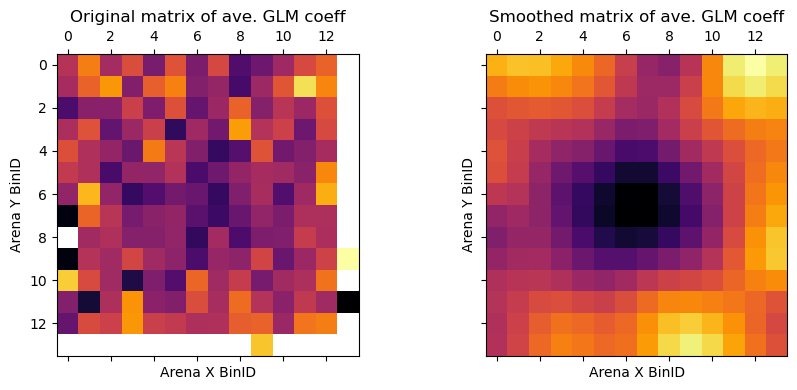

In [23]:
#heatmap of average GLM coeff magnitude per position bin overlayed on the arena, just for the position selection neurons (Good =1)

from scipy import sparse
from scipy.ndimage import gaussian_filter

# set nans to 0
AveInt = copy.deepcopy(AverageIntensity)
#masked_image = np.ma.masked_array(AveInt, np.isnan(AveInt))
# Apply Gaussian filter
#smoothed_matrix = gaussian_filter(masked_image, sigma=2)

AveInt[np.isnan(AveInt)] = np.nanmean(AveInt)

# smooth the matrix
smoothed_matrix = gaussian_filter(AveInt, sigma=1.5)

# Set 0s to None as they will be ignored when plotting
# smoothed_matrix[smoothed_matrix == 0] = None
AveInt[AveInt == np.nanmean(AveInt)] = math.nan

# Plot the data
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2,
                               sharex=False, sharey=True,
                               figsize=(9, 4))
ax1.matshow(AverageIntensity,cmap='inferno')
ax1.set_title("Original matrix of ave. GLM coeff")
ax1.set_xlabel('Arena X BinID')
ax1.set_ylabel('Arena Y BinID')
ax2.matshow(smoothed_matrix,cmap='inferno')
ax2.set_title("Smoothed matrix of ave. GLM coeff")
ax2.set_xlabel('Arena X BinID')
ax2.set_ylabel('Arena Y BinID')
plt.tight_layout()
plt.show()

In [24]:
df_coeffs = pd.DataFrame(index=range(num_bins_x*num_bins_y), columns=range(3))
df_coeffs.columns = ['X', 'Y','Z']

xx = np.linspace(1, 1, num_bins_x)
yy = np.linspace(1, 1, num_bins_y)
X, Y = np.meshgrid(xx, yy)

for i in range(num_bins_x):
    for j in range(num_bins_y):
        df_coeffs.loc[i*14+j, 'X'] = i
        df_coeffs.loc[i*14+j, 'Y'] = j
        df_coeffs.loc[i*14+j, 'Z'] = AverageIntensity[i,j]

dR = copy.deepcopy(GoodWeightdX)

for i in range(len(GoodWeightdX)):
    dR[i] = int(np.sqrt(GoodWeightdX[i]*GoodWeightdX[i] + GoodWeightdY[i]*GoodWeightdY[i]))

df_RvsCoeff = pd.DataFrame(index=range(len(GoodWeightList)), columns=range(2))
df_RvsCoeff.columns = ['dR', 'Coeff']

for j in range(len(GoodWeightList)):
        df_RvsCoeff.loc[j, 'dR'] = str(dR[j])
        df_RvsCoeff.loc[j, 'Coeff'] = GoodWeightListAbs[j]

df_RvsCoeff['dR'] = df_RvsCoeff['dR'].astype('category')
df_RvsCoeff['Coeff'] = df_RvsCoeff['Coeff'].astype('float')
#sns.boxplot(data=df_RvsCoeff, x="Coeff", y="dY",notch=True,showfliers=False,order=["-6.5", "-5.5","-4.5","-3.5","-2.5","-1.5","-0.5","0.5","1.5","2.5","3.5","4.5","5.5","6.5"])
#sns.boxplot(GoodWeightdY,GoodWeightList)

# Group data by the categorical column
categories = df_RvsCoeff['dR'].unique()
#boxplot_data = [df_RvsCoeff[df_RvsCoeff['dR'] == category]['Coeff'] for category in categories]

# Create the boxplot
#plt.boxplot(boxplot_data, labels=categories,showfliers=False,bootstrap=None, meanline=False, showmeans=True,whis=(25, 75),notch=True)
#plt.title('Boxplot by Category')
#plt.xlabel('Radial Distance from Origin (# of Bins)')
#plt.ylabel('GLM Position Selectivity Coeff.')
#plt.show()

#plt.boxplot(boxplot_data, labels=categories)
#plt.title('Boxplot by Category')
#plt.xlabel('Category')
#plt.ylabel('Values')
#plt.show()

C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2435949030.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_RvsCoeff.groupby('dR')['Coeff'].agg(['mean', 'count', 'std'])
C:\Users\ryanb\AppData\Local\Temp\ipykernel_39368\2435949030.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=df_RvsCoeff, x='dR', y='Coeff', ci=None, color='blue', markers='o', linestyles='-',markersize=10)


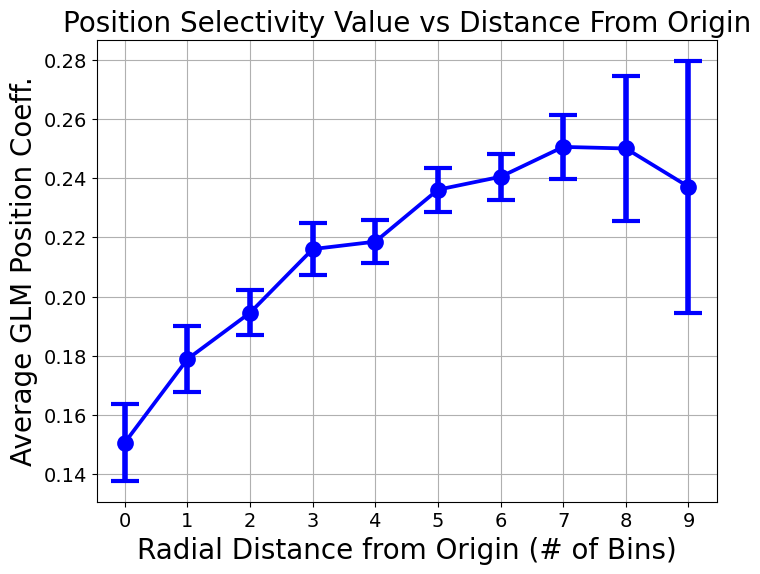

In [25]:
from scipy.stats import sem, t
# Calculate mean and 95% CI of GLM coeffs radially away from origin (48, 48) in original 96 x 96 arena
summary = df_RvsCoeff.groupby('dR')['Coeff'].agg(['mean', 'count', 'std'])
#print(summary)
confidence = 0.95
summary['sem'] = summary['std'] / np.sqrt(summary['count'])  # Standard error
summary['margin_of_error'] = summary['sem'] * t.ppf((1 + confidence) / 2, summary['count'] - 1)
summary['lower_ci'] = summary['mean'] - summary['margin_of_error']
summary['upper_ci'] = summary['mean'] + summary['margin_of_error']

# Plot
plt.figure(figsize=(8, 6))
sns.pointplot(data=df_RvsCoeff, x='dR', y='Coeff', ci=None, color='blue', markers='o', linestyles='-',markersize=10)
for i, row in summary.iterrows():
    plt.errorbar(x=i, y=row['mean'], yerr=row['margin_of_error'], fmt='o', color='blue', capsize=10,linewidth=4,elinewidth=4,markeredgewidth=3)

plt.title('Position Selectivity Value vs Distance From Origin',fontsize=20)
plt.ylabel('Average GLM Position Coeff.',fontsize=20)
plt.xlabel('Radial Distance from Origin (# of Bins)',fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(True)
plt.show()

In [26]:
# number of position-selective neurons in the GRU/LSTM
len(GoodIDList)

163

In [27]:

#GoodWeightList = []
#GoodWeightListAbs = []
#GoodWeightdX = []
#GoodWeightdY = 
#plt.scatter(dR,GoodWeightListAbs,s=5)
#plt.show()
#plt.scatter(GoodWeightdX,GoodWeightList,s=5)
#plt.show()
#plt.scatter(GoodWeightdY,GoodWeightList,s=5)
#plt.show()

In [28]:

#Z = np.sin(np.sqrt(X**2 + Y**2))


        